# CyberShield AI
## GPU-Accelerated Network Intrusion Detection Using RAPIDS

**Course:** Scalable Data Science  
**Dataset:** Network Intrusion Dataset (CIC-IDS2017)  
**Kaggle handle:** `chethuhn/network-intrusion-dataset`  
**Task:** Binary classification  
**Target:**
- `0` = Benign traffic
- `1` = Malicious traffic

### Project objectives
1. Download the dataset with `kagglehub`.
2. Load and process between **1,000,000 and 1,500,000 records** using `cuDF`.
3. Train and compare three GPU-based models using `cuML`.
4. Record GPU utilization, GPU memory, loading time, preprocessing time, training time, and inference time.
5. Evaluate the trade-off between model quality and GPU resource consumption.
6. Produce practical cybersecurity insights.

## 1. Problem Statement

Modern networks generate millions of flows, making manual inspection impossible. Malicious traffic such as denial-of-service attacks, brute-force attempts, bot activity, port scanning, infiltration, and web attacks can cause service disruption and data loss.

### Research question
**Can GPU-accelerated machine learning detect malicious network flows accurately and efficiently on a dataset containing more than one million records?**

### Practical value
The system can support security teams by:
- identifying suspicious network flows.
- prioritizing high-risk traffic.
- reducing manual investigation.
- demonstrating the value of GPU acceleration for large-scale cybersecurity analytics.

## 2. Project Workflow

1. Verify the NVIDIA GPU.
2. Download the latest Kaggle dataset version with `kagglehub`.
3. Discover available CSV or Parquet files automatically.
4. Load a maximum of 1.5 million rows with `cuDF`.
5. Normalize column names and detect the label.
6. Perform data-quality checks.
7. Clean duplicates, missing values, infinity, and unusable columns.
8. Create the binary intrusion target.
9. Perform **Feature Engineering before EDA**.
10. Perform visual EDA on important original and engineered features.
11. Prepare the final feature matrix.
12. Split and scale the data.
13. Train Logistic Regression, Random Forest, and Linear SVC with `cuML`.
14. Compare accuracy, precision, recall, F1, GPU utilization, GPU memory, training time, and inference time.
15. Run a controlled CPU/GPU comparison.
16. Export measured results.

## 3. Google Colab GPU Setup

Select **Runtime → Change runtime type → GPU**.

In [1]:
!nvidia-smi

Sun Aug  9 17:12:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install RAPIDS in Google Colab only when cudf and cuml are unavailable.
!git clone -q https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
/content/rapidsai-csp-utils/colab/pip-install.py:10: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
Installing RAPIDS remaining 26.02 libraries
Using Python 3.12.13 environment at: /usr
Checked 11 packages in 168ms

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do not run any further installation from the conda based installation methods, as they may cause issues!

        Please ensure that you're pulling from the git repo to remain updated with the latest working install scripts.

        Troubleshooting:
            - If there is an installation failure, please check back on RAPIDSAI owned templates/notebooks to see how to

## 4. Install Dependencies

`kagglehub.dataset_download()` downloads the complete dataset to a local cache.  
The notebook then uses `cuDF` for actual large-scale data loading and preprocessing.

In [3]:
!pip -q install kagglehub pynvml

## 5. Imports and Configuration

I select data 1 m to 1.5 m

In [4]:
import gc
import json
import re
import time
import threading
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import cudf
import cupy as cp

from cuml.model_selection import train_test_split
from cuml.preprocessing import StandardScaler
from cuml.linear_model import LogisticRegression
from cuml.ensemble import RandomForestClassifier
from cuml.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
MIN_ROWS = 1_000_000
MAX_ROWS = 1_500_000
PER_FILE_LIMIT = 220_000
CPU_BASELINE_ROWS = 250_000
BALANCE_TRAINING = True
MAX_BENIGN_TO_ATTACK_RATIO = 3.0

cp.random.seed(RANDOM_STATE)

print("cuDF version:", cudf.__version__)

cuDF version: 26.02.01


## 6. GPU Monitoring Utility

The utility samples GPU utilization and memory while a workflow operation is running.

In [5]:
from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetMemoryInfo,
)

class GPUMonitor:
    def __init__(self, interval=0.20, device_index=0):
        self.interval = interval
        self.device_index = device_index
        self.samples = []
        self.elapsed_seconds = np.nan
        self._running = False
        self._thread = None

    def _collect(self):
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(self.device_index)

        while self._running:
            util = nvmlDeviceGetUtilizationRates(handle)
            memory = nvmlDeviceGetMemoryInfo(handle)
            self.samples.append({
                "gpu_util_percent": float(util.gpu),
                "memory_used_mb": float(memory.used / (1024 ** 2)),
                "memory_total_mb": float(memory.total / (1024 ** 2)),
            })
            time.sleep(self.interval)

        nvmlShutdown()

    def __enter__(self):
        self.samples = []
        self._running = True
        self._start = time.perf_counter()
        self._thread = threading.Thread(
            target=self._collect,
            daemon=True,
        )
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self._running = False
        self._thread.join()
        self.elapsed_seconds = time.perf_counter() - self._start

    def summary(self, prefix=""):
        output = {
            f"{prefix}time_seconds": self.elapsed_seconds,
            f"{prefix}avg_gpu_util_percent": np.nan,
            f"{prefix}max_gpu_util_percent": np.nan,
            f"{prefix}avg_memory_used_mb": np.nan,
            f"{prefix}max_memory_used_mb": np.nan,
        }

        if self.samples:
            frame = pd.DataFrame(self.samples)
            output.update({
                f"{prefix}avg_gpu_util_percent":
                    frame["gpu_util_percent"].mean(),
                f"{prefix}max_gpu_util_percent":
                    frame["gpu_util_percent"].max(),
                f"{prefix}avg_memory_used_mb":
                    frame["memory_used_mb"].mean(),
                f"{prefix}max_memory_used_mb":
                    frame["memory_used_mb"].max(),
            })

        return output

## 7. Download the Dataset with KaggleHub

In a Kaggle notebook, authentication is automatic.  
In Colab, `kagglehub.login()` may prompt for a Kaggle token if authentication is needed.

In [6]:
# Uncomment only when authentication is requested.
# kagglehub.login()
dataset_path = Path(
    kagglehub.dataset_download(
        "chethuhn/network-intrusion-dataset"
    )
)

print("Dataset directory:", dataset_path)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset directory: /kaggle/input/network-intrusion-dataset


In [7]:
all_files = sorted(
    path for path in dataset_path.rglob("*")
    if path.is_file()
)

print(f"Discovered {len(all_files)} files:")
for path in all_files:
    print(
        f"- {path.relative_to(dataset_path)} "
        f"({path.stat().st_size / (1024 ** 2):.2f} MB)"
    )

Discovered 8 files:
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (73.55 MB)
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (73.34 MB)
- Friday-WorkingHours-Morning.pcap_ISCX.csv (55.62 MB)
- Monday-WorkingHours.pcap_ISCX.csv (168.73 MB)
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (79.25 MB)
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv (49.61 MB)
- Tuesday-WorkingHours.pcap_ISCX.csv (128.82 MB)
- Wednesday-workingHours.pcap_ISCX.csv (214.74 MB)


## 8. Discover Tabular Data Files

The dataset version may contain several CSV files. The code also supports Parquet when available.

In [8]:
csv_files = sorted(dataset_path.rglob("*.csv"))
parquet_files = sorted(dataset_path.rglob("*.parquet"))

if csv_files:
    tabular_files = csv_files
    file_type = "csv"
elif parquet_files:
    tabular_files = parquet_files
    file_type = "parquet"
else:
    raise FileNotFoundError(
        "No CSV or Parquet files were found in the downloaded dataset."
    )

print("Selected type:", file_type)
print("Selected files:", len(tabular_files))

for path in tabular_files:
    print("-", path.name)

Selected type: csv
Selected files: 8
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- Friday-WorkingHours-Morning.pcap_ISCX.csv
- Monday-WorkingHours.pcap_ISCX.csv
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- Tuesday-WorkingHours.pcap_ISCX.csv
- Wednesday-workingHours.pcap_ISCX.csv


## 9. Load 1.0-1.5 Million Rows with cuDF

To preserve traffic variety reads a limited number of rows from every file rather than taking only the first file. The combined dataset is then capped at 1.5 million rows.

In [9]:
gpu_frames = []

with GPUMonitor() as load_monitor:
    for index, path in enumerate(tabular_files, start=1):
        print(
            f"Loading {index}/{len(tabular_files)}: {path.name}"
        )

        if file_type == "csv":
            part = cudf.read_csv(
                path,
                nrows=PER_FILE_LIMIT
            )

        elif file_type == "parquet":
            part = cudf.read_parquet(path)

            if len(part) > PER_FILE_LIMIT:
                part = part.sample(
                    n=PER_FILE_LIMIT,
                    random_state=RANDOM_STATE
                )

        else:
            raise ValueError(
                f"Unsupported file type: {file_type}"
            )

        # إضافة اسم الملف لمعرفة مصدر كل سجل
        part["source_file"] = path.name

        gpu_frames.append(part)

    # دمج جميع الملفات
    raw_df = cudf.concat(
        gpu_frames,
        ignore_index=True
    )

    # تحديد الحد الأعلى بـ 1.5 مليون سجل
    if len(raw_df) > MAX_ROWS:
        raw_df = raw_df.sample(
            n=MAX_ROWS,
            random_state=RANDOM_STATE
        ).reset_index(drop=True)

load_metrics = load_monitor.summary(prefix="load_")

# تنظيف الذاكرة
del gpu_frames
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

print(f"Loaded rows: {len(raw_df):,}")
print(f"Loaded columns: {len(raw_df.columns):,}")
print("GPU loading metrics:")
print(load_metrics)

# التأكد من الوصول إلى مليون سجل على الأقل
if len(raw_df) < MIN_ROWS:
    print(
        f"WARNING: Only {len(raw_df):,} rows were loaded. "
        "Increase PER_FILE_LIMIT to load at least one million rows."
    )
else:
    print(
        "Dataset size requirement satisfied: "
        f"{len(raw_df):,} rows loaded."
    )

raw_df.head()

Loading 1/8: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading 2/8: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading 3/8: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading 4/8: Monday-WorkingHours.pcap_ISCX.csv
Loading 5/8: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading 6/8: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading 7/8: Tuesday-WorkingHours.pcap_ISCX.csv
Loading 8/8: Wednesday-workingHours.pcap_ISCX.csv
Loaded rows: 1,500,000
Loaded columns: 80
GPU loading metrics:
{'load_time_seconds': 2.993811645000278, 'load_avg_gpu_util_percent': np.float64(21.0), 'load_max_gpu_util_percent': 48.0, 'load_avg_memory_used_mb': np.float64(1739.110576923077), 'load_max_memory_used_mb': 4166.1875}
Dataset size requirement satisfied: 1,500,000 rows loaded.


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54324,1000012,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
1,53,47132,2,2,104,220,52,52,52.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Thursday-WorkingHours-Morning-WebAttacks.pcap_...
2,80,690401,3,5,26,11607,20,0,8.666667,10.263203,...,0.0,0.0,0,0,0.0,0.0,0,0,DDoS,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,53,31241,1,1,39,117,39,39,39.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Tuesday-WorkingHours.pcap_ISCX.csv
4,443,9064711,3,0,0,0,0,0,0.000000,0.000000,...,3063963.0,0.0,3063963,3063963,6000748.0,0.0,6000748,6000748,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv


## 10. Normalize Column Names and Detect the Label

In [10]:
def normalize_column_name(name):
    normalized = str(name).strip()
    normalized = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        normalized,
    )
    return normalized.strip("_").lower()

normalized_names = [
    normalize_column_name(column)
    for column in raw_df.columns
]

# Make duplicate normalized names unique.
seen = {}
unique_names = []

for name in normalized_names:
    count = seen.get(name, 0)
    unique_names.append(
        name if count == 0 else f"{name}_{count}"
    )
    seen[name] = count + 1

raw_df.columns = unique_names

label_candidates = [
    column for column in raw_df.columns
    if column in {
        "label",
        "class",
        "attack",
        "attack_type",
        "target",
    }
    or "label" in column
]

if not label_candidates:
    raise KeyError(
        "No label column was detected. Available columns:\n"
        + "\n".join(raw_df.columns)
    )

LABEL_COLUMN = label_candidates[0]

print("Detected label column:", LABEL_COLUMN)
print(raw_df[LABEL_COLUMN].value_counts().head(30))

Detected label column: label
label
BENIGN                        1125098
DoS Hulk                       122530
PortScan                       114678
DDoS                           114258
FTP-Patator                      7063
DoS slowloris                    5126
DoS Slowhttptest                 4895
SSH-Patator                      2649
Bot                              1749
Web Attack � Brute Force         1326
Web Attack � XSS                  582
Infiltration                       29
Web Attack � Sql Injection         17
Name: count, dtype: int64


## 11. Data Quality Analysis

In [11]:
print("Dataset shape:", raw_df.shape)
print("Complete duplicate rows:", int(raw_df.duplicated().sum()))

missing_summary = (
    raw_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"]
    / len(raw_df)
    * 100
)

missing_summary.head(20)

Dataset shape: (1500000, 80)
Complete duplicate rows: 126198


,missing_count,missing_percent
flow_bytes_s,651,0.0434
destination_port,0,0.0000
flow_duration,0,0.0000
total_fwd_packets,0,0.0000
total_backward_packets,0,0.0000
total_length_of_fwd_packets,0,0.0000
total_length_of_bwd_packets,0,0.0000
fwd_packet_length_max,0,0.0000
fwd_packet_length_min,0,0.0000
fwd_packet_length_mean,0,0.0000


In [12]:
original_label_counts = (
    raw_df[LABEL_COLUMN]
    .astype("str")
    .str.strip()
    .value_counts()
)

original_label_counts.head(30)

label
BENIGN                        1125098
DoS Hulk                       122530
PortScan                       114678
DDoS                           114258
FTP-Patator                      7063
DoS slowloris                    5126
DoS Slowhttptest                 4895
SSH-Patator                      2649
Bot                              1749
Web Attack � Brute Force         1326
Web Attack � XSS                  582
Infiltration                       29
Web Attack � Sql Injection         17
Name: count, dtype: int64

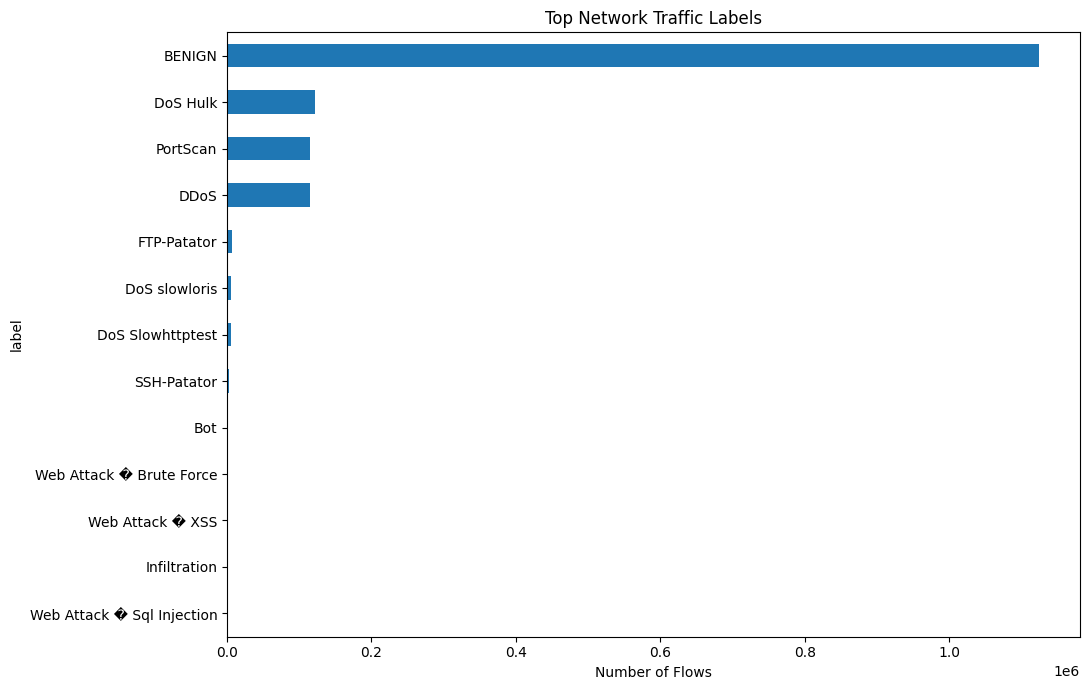

In [13]:
label_plot = (
    original_label_counts
    .head(20)
    .to_pandas()
    .sort_values()
)

plt.figure(figsize=(11, 7))
label_plot.plot(kind="barh")
plt.title("Top Network Traffic Labels")
plt.xlabel("Number of Flows")
plt.tight_layout()
plt.show()

## 12. Data Cleaning

Before feature engineering and EDA I clean the data once. This makes the visualizations and models use the same high-quality dataset.

Steps:
1. Remove exact duplicate rows.
2. Convert feature columns to numeric values.
3. Replace positive/negative infinity with missing values.
4. Impute numeric missing values using the median.
5. Remove empty and constant columns.
6. Keep the original label for analysis, then create the binary target.

In [14]:
# Data Cleaning with GPU Monitoring
with GPUMonitor() as preprocessing_monitor:

    # Keep a copy of the original label and source file for EDA.
    print(f"Rows before cleaning: {len(raw_df):,}")
    print(
        f"Duplicates before cleaning: "
        f"{int(raw_df.duplicated().sum()):,}"
    )

    # 1) Remove exact duplicate rows.
    raw_df = raw_df.drop_duplicates().reset_index(drop=True)

    # 2) Create the binary target before removing the original label.
    label_text = (
        raw_df[LABEL_COLUMN]
        .astype("str")
        .str.strip()
        .str.lower()
    )

    raw_df["is_attack"] = (
        ~label_text.isin(["benign", "normal", "0"])
    ).astype("int32")

    # 3) Identify columns that should never be model features.
    identifier_patterns = [
        "flow_id",
        "source_ip",
        "destination_ip",
        "src_ip",
        "dst_ip",
        "timestamp",
        "source_file",
    ]

    excluded_columns = {
        LABEL_COLUMN,
        "is_attack"
    }

    for column in raw_df.columns:
        if any(
            pattern == column or pattern in column
            for pattern in identifier_patterns
        ):
            excluded_columns.add(column)

    candidate_features = [
        column
        for column in raw_df.columns
        if column not in excluded_columns
    ]

    # 4) Convert model candidates to numeric and clean infinity / missing values.
    cleaned_features = cudf.DataFrame(
        index=raw_df.index
    )

    removed_features = []

    for column in candidate_features:

        numeric_column = cudf.to_numeric(
            raw_df[column],
            errors="coerce"
        )

        # Replace infinity values with NaN
        numeric_column = numeric_column.replace(
            [cp.inf, -cp.inf],
            cp.nan
        )

        non_null_count = int(
            numeric_column.notnull().sum()
        )

        unique_count = int(
            numeric_column.nunique(dropna=True)
        )

        # Remove empty or constant features
        if non_null_count == 0 or unique_count <= 1:
            removed_features.append(column)
            continue

        # Fill missing values using median
        median_value = numeric_column.median()

        cleaned_features[column] = (
            numeric_column
            .fillna(median_value)
            .astype("float32")
        )

    # Preserve analysis columns.
    cleaned_features[LABEL_COLUMN] = (
        raw_df[LABEL_COLUMN]
    )

    cleaned_features["is_attack"] = (
        raw_df["is_attack"]
    )

    if "source_file" in raw_df.columns:
        cleaned_features["source_file"] = (
            raw_df["source_file"]
        )

    # Final cleaned dataframe
    df = cleaned_features.reset_index(drop=True)


# Get GPU preprocessing metrics
preprocessing_metrics = (
    preprocessing_monitor.summary(
        prefix="preprocessing_"
    )
)


# Cleaning Summary
print(f"Rows after duplicate removal: "f"{len(df):,}")

print(f"Numeric features retained: "f"{len(candidate_features) - len(removed_features)}")

print(f"Removed empty/constant features: "f"{len(removed_features)}")

print("Remaining missing values in numeric features:",int(df.select_dtypes(include=["number"]).isnull().sum().sum()))

print("\nGPU Preprocessing Metrics:")
print(preprocessing_metrics)

Rows before cleaning: 1,500,000
Duplicates before cleaning: 126,198
Rows after duplicate removal: 1,373,802
Numeric features retained: 70
Removed empty/constant features: 8
Remaining missing values in numeric features: 0

GPU Preprocessing Metrics:
{'preprocessing_time_seconds': 3.525090337000165, 'preprocessing_avg_gpu_util_percent': np.float64(30.88235294117647), 'preprocessing_max_gpu_util_percent': 55.0, 'preprocessing_avg_memory_used_mb': np.float64(2945.8345588235293), 'preprocessing_max_memory_used_mb': 3212.1875}


## 13. Feature Engineering

CIC-IDS2017 already contains many network-flow measurements and this project keeps Feature Engineering simple and interpretable by creating only two meaningful features before EDA.

New features:

- `avg_bytes_per_packet`: measures the average amount of data transferred per network packet.
- `fwd_bwd_packet_ratio`: measures the balance between forward and backward packet counts.

These two features are useful because malicious traffic may show unusual packet-size behavior or an imbalance in communication direction compared with benign traffic.

A small epsilon is added to denominators to avoid division by zero.

In [15]:
#Create only two meaningful new features
EPS = 1e-6

engineered_features = []

# 1. Average Bytes per Packet
required_cols_1 = [
    "total_fwd_packets",
    "total_backward_packets",
    "total_length_of_fwd_packets",
    "total_length_of_bwd_packets"
]

if all(col in df.columns for col in required_cols_1):

    total_packets = (
        df["total_fwd_packets"]
        + df["total_backward_packets"]
    )

    total_bytes = (
        df["total_length_of_fwd_packets"]
        + df["total_length_of_bwd_packets"]
    )

    df["avg_bytes_per_packet"] = (
        total_bytes / (total_packets + EPS)
    ).astype("float32")

    engineered_features.append(
        "avg_bytes_per_packet"
    )


# 2. Forward / Backward Packet Ratio
required_cols_2 = [
    "total_fwd_packets",
    "total_backward_packets"
]

if all(col in df.columns for col in required_cols_2):

    df["fwd_bwd_packet_ratio"] = (
        df["total_fwd_packets"]
        / (df["total_backward_packets"] + EPS)
    ).astype("float32")

    engineered_features.append(
        "fwd_bwd_packet_ratio"
    )


# Clean possible infinity / NaN values
for col in engineered_features:

    df[col] = (
        df[col]
        .replace([cp.inf, -cp.inf], cp.nan)
        .fillna(0)
        .astype("float32")
    )


print("Feature Engineering Completed")

for feature in engineered_features:
    print("Created:", feature)

print("\nDataset Shape After Feature Engineering:",df.shape)

Feature Engineering Completed
Created: avg_bytes_per_packet
Created: fwd_bwd_packet_ratio

Dataset Shape After Feature Engineering: (1373802, 75)


## 14. Exploratory Data Analysis (EDA)

The EDA focuses on the most useful plots rather than plotting every feature.

I will visualize:
1. Detailed traffic-label distribution.
2. Benign vs attack class balance.
3. Traffic source/file distribution.
4. Correlation of the strongest numeric features with the attack target.
5. Selected engineered-feature distributions by class.
6. A compact correlation heatmap for the most relevant features.

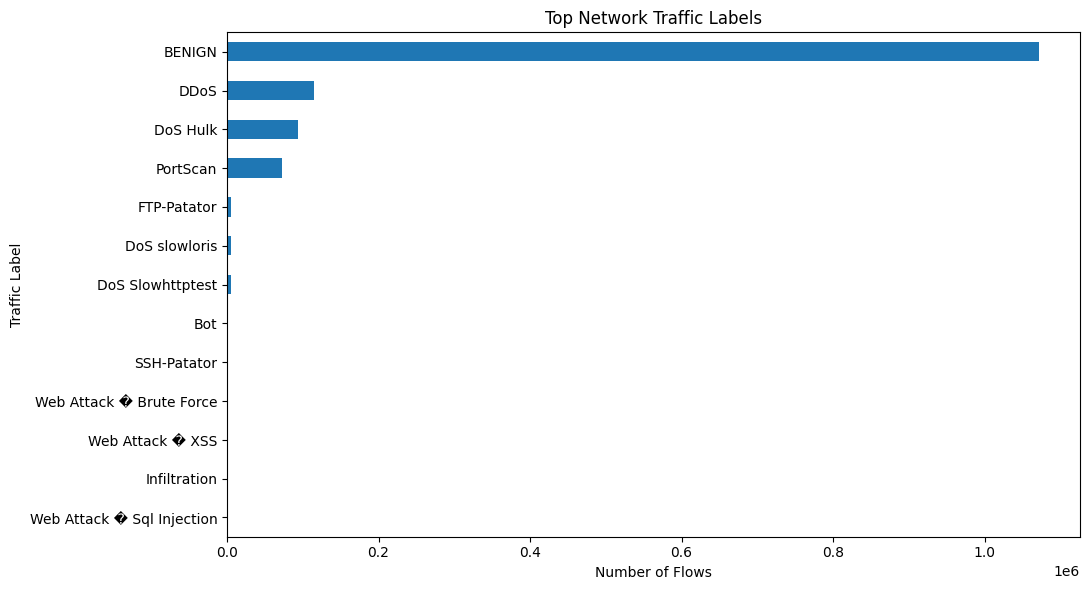

In [16]:
#Plot 1: Top detailed traffic labels
label_counts = (
    df[LABEL_COLUMN]
    .astype("str")
    .str.strip()
    .value_counts()
    .head(15)
    .to_pandas()
    .sort_values()
)

plt.figure(figsize=(11, 6))
label_counts.plot(kind="barh")
plt.title("Top Network Traffic Labels")
plt.xlabel("Number of Flows")
plt.ylabel("Traffic Label")
plt.tight_layout()
plt.show()

The dataset is highly imbalanced with BENIGN traffic dominating the majority of network flows. Among the attacks, DDoS, DoS Hulk, and PortScan are the most common.

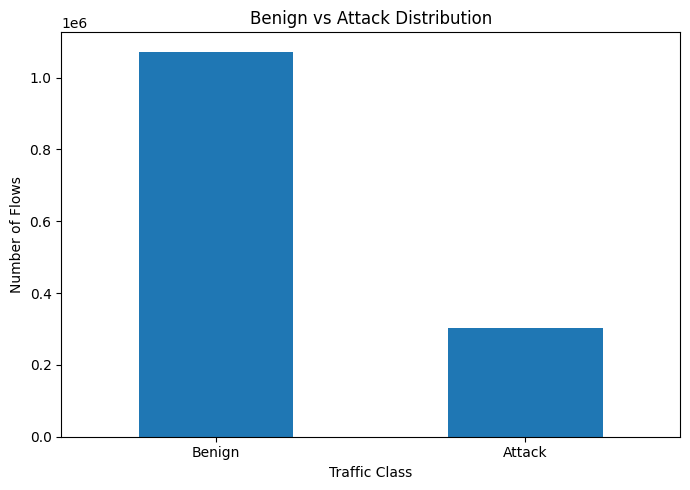

Benign    1072232
Attack     301570
Name: count, dtype: int64

Attack percentage: 21.95 %


In [17]:
#Plot 2: Benign vs Attack distribution
binary_counts = (
    df["is_attack"]
    .value_counts()
    .sort_index()
    .to_pandas()
)

binary_counts.index = ["Benign", "Attack"]

plt.figure(figsize=(7, 5))
binary_counts.plot(kind="bar")
plt.title("Benign vs Attack Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Flows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(binary_counts)
print("\nAttack percentage:",round(binary_counts["Attack"] / binary_counts.sum() * 100, 2), "%")

The dataset shows a clear class imbalance and with 1,072,232 benign flows compared to 301,570 attack flows. Attack traffic represents approximately 21.95% of the dataset indicating that class imbalance should be considered during model training.

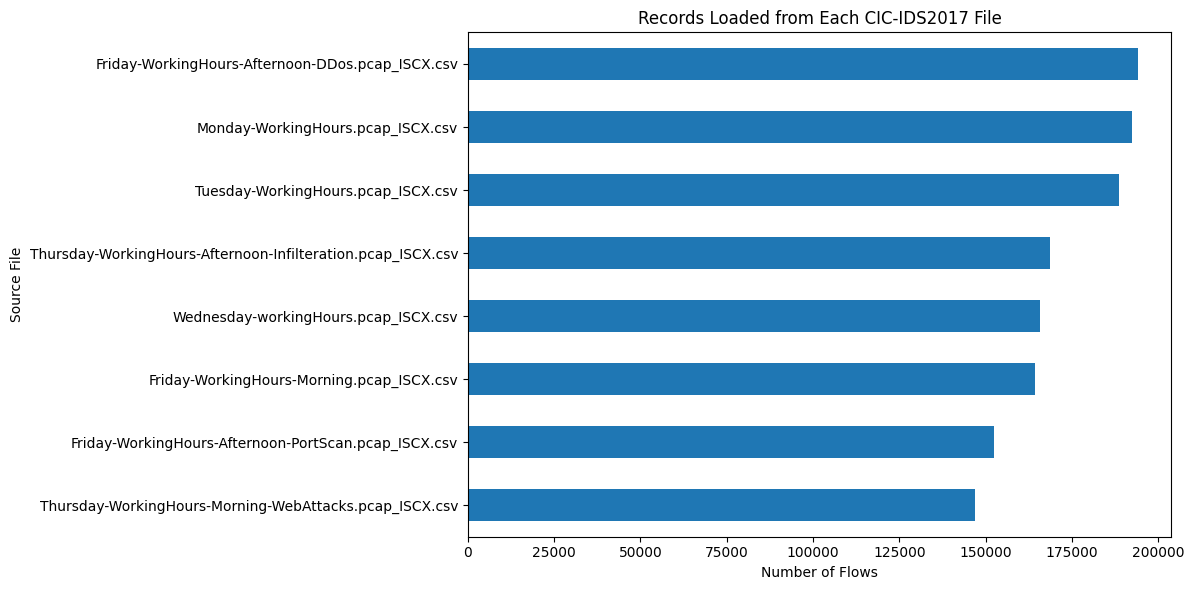

In [18]:
# Plot 3: Number of records contributed by each source file
if "source_file" in df.columns:
    source_counts = (
        df["source_file"]
        .value_counts()
        .to_pandas()
        .sort_values()
    )

    plt.figure(figsize=(12, 6))
    source_counts.plot(kind="barh")
    plt.title("Records Loaded from Each CIC-IDS2017 File")
    plt.xlabel("Number of Flows")
    plt.ylabel("Source File")
    plt.tight_layout()
    plt.show()

The records are distributed across all eight CIC-IDS2017 files and with each file contributing roughly 145,000–195,000 flows. This provides data from different days and network activities instead of relying on a single source file and which improves the diversity of the dataset.

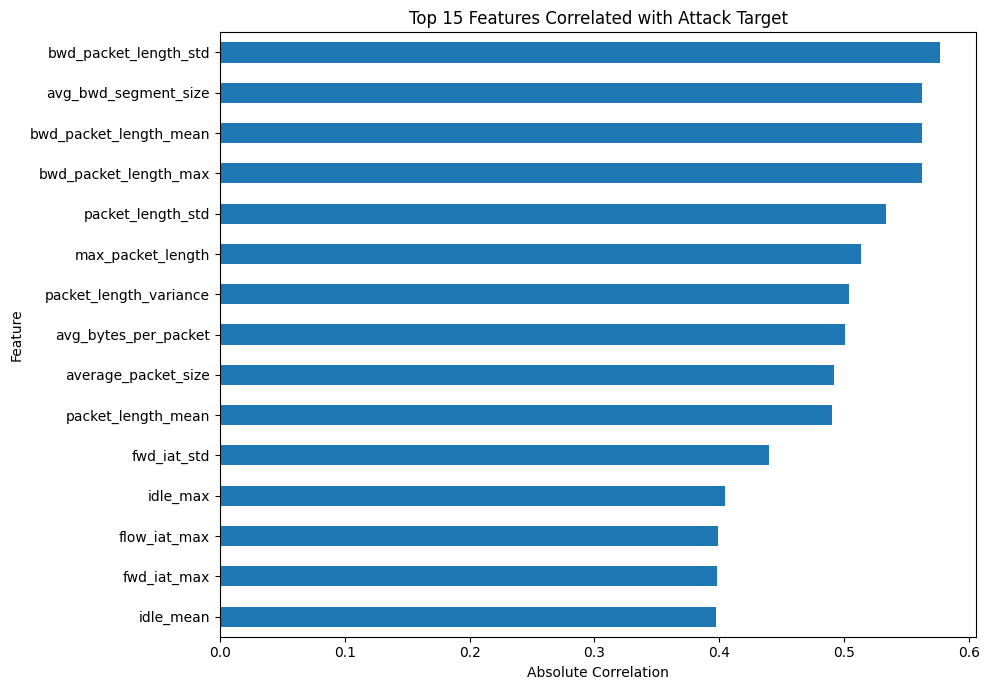

bwd_packet_length_std     0.577005
bwd_packet_length_mean    0.562562
avg_bwd_segment_size      0.562562
bwd_packet_length_max     0.561920
packet_length_std         0.533636
max_packet_length         0.513703
packet_length_variance    0.503395
avg_bytes_per_packet      0.500532
average_packet_size       0.491874
packet_length_mean        0.490435
fwd_iat_std               0.440008
idle_max                  0.404208
flow_iat_max              0.398607
fwd_iat_max               0.397947
idle_mean                 0.397259
Name: is_attack, dtype: float64

In [19]:
# Numeric features available for modeling
non_model_columns = {LABEL_COLUMN, "is_attack", "source_file"}
model_features = [
    col for col in df.columns
    if col not in non_model_columns
]

# Correlation with target using GPU
correlations = (
    df[model_features + ["is_attack"]]
    .corr()["is_attack"]
    .drop("is_attack")
    .abs()
    .sort_values(ascending=False)
)

top_corr = correlations.head(15).to_pandas().sort_values()

plt.figure(figsize=(10, 7))
top_corr.plot(kind="barh")
plt.title("Top 15 Features Correlated with Attack Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

correlations.head(15)

The results show that packet size related features have the strongest correlation with attack traffic. And bwd_packet_length_std has the highest correlation at about 0.58 and followed by features such as bwd_packet_length_mean and avg_bwd_segment_size. This suggests that packet size and backward traffic behavior are useful indicators for distinguishing attacks from benign traffic.

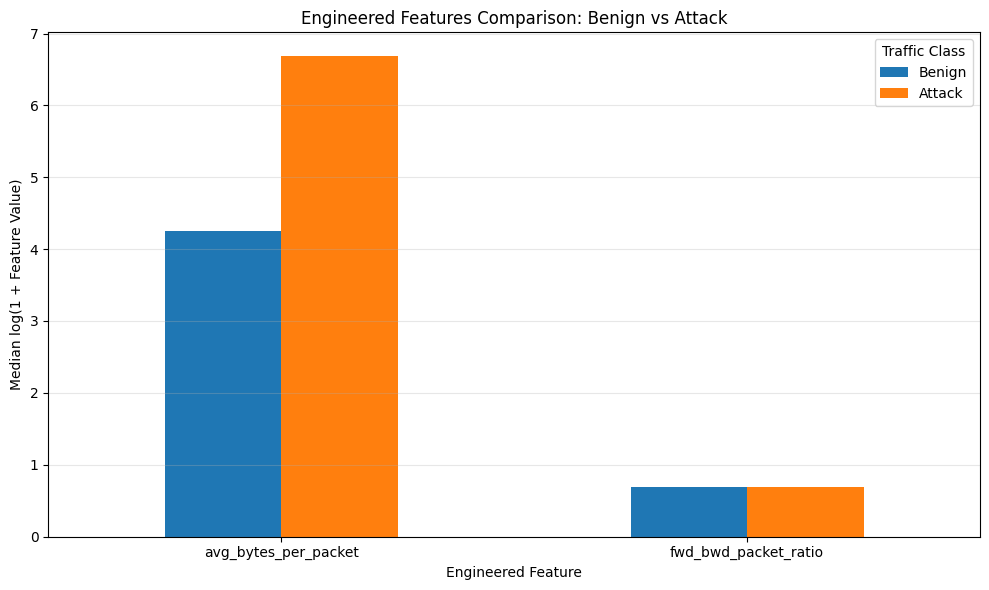

,Benign,Attack
Feature,,
avg_bytes_per_packet,4.247066,6.682860
fwd_bwd_packet_ratio,0.693147,0.693147


In [20]:
# Plot 5: Engineered Features Comparison by Traffic Class
# Compare the median value of each engineered feature

EDA_SAMPLE_SIZE = min(100_000, len(df))

eda_sample = (
    df.sample(
        n=EDA_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .to_pandas()
)

eda_sample["traffic_class"] = eda_sample["is_attack"].map({
    0: "Benign",
    1: "Attack"
})

features_to_plot = [
    "avg_bytes_per_packet",
    "fwd_bwd_packet_ratio"
]

# Store median values for each class
comparison_data = []

for feature in features_to_plot:

    if feature not in eda_sample.columns:
        continue

    feature_data = eda_sample[
        ["traffic_class", feature]
    ].dropna().copy()

    # Remove negative values if any
    feature_data = feature_data[
        feature_data[feature] >= 0
    ]

    # Log transformation only for visualization
    feature_data["plot_value"] = np.log1p(
        feature_data[feature]
    )

    benign_median = feature_data.loc[
        feature_data["traffic_class"] == "Benign",
        "plot_value"
    ].median()

    attack_median = feature_data.loc[
        feature_data["traffic_class"] == "Attack",
        "plot_value"
    ].median()

    comparison_data.append({
        "Feature": feature,
        "Benign": benign_median,
        "Attack": attack_median
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df = comparison_df.set_index("Feature")

# Plot
comparison_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Engineered Features Comparison: Benign vs Attack")

plt.xlabel("Engineered Feature")

plt.ylabel("Median log(1 + Feature Value)")

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Traffic Class"
)

plt.tight_layout()
plt.show()

comparison_df

avg_bytes_per_packet shows a clear difference between benign and attack traffic and while fwd_bwd_packet_ratio has similar values for both classes. And the first feature appears more useful for attack detection.

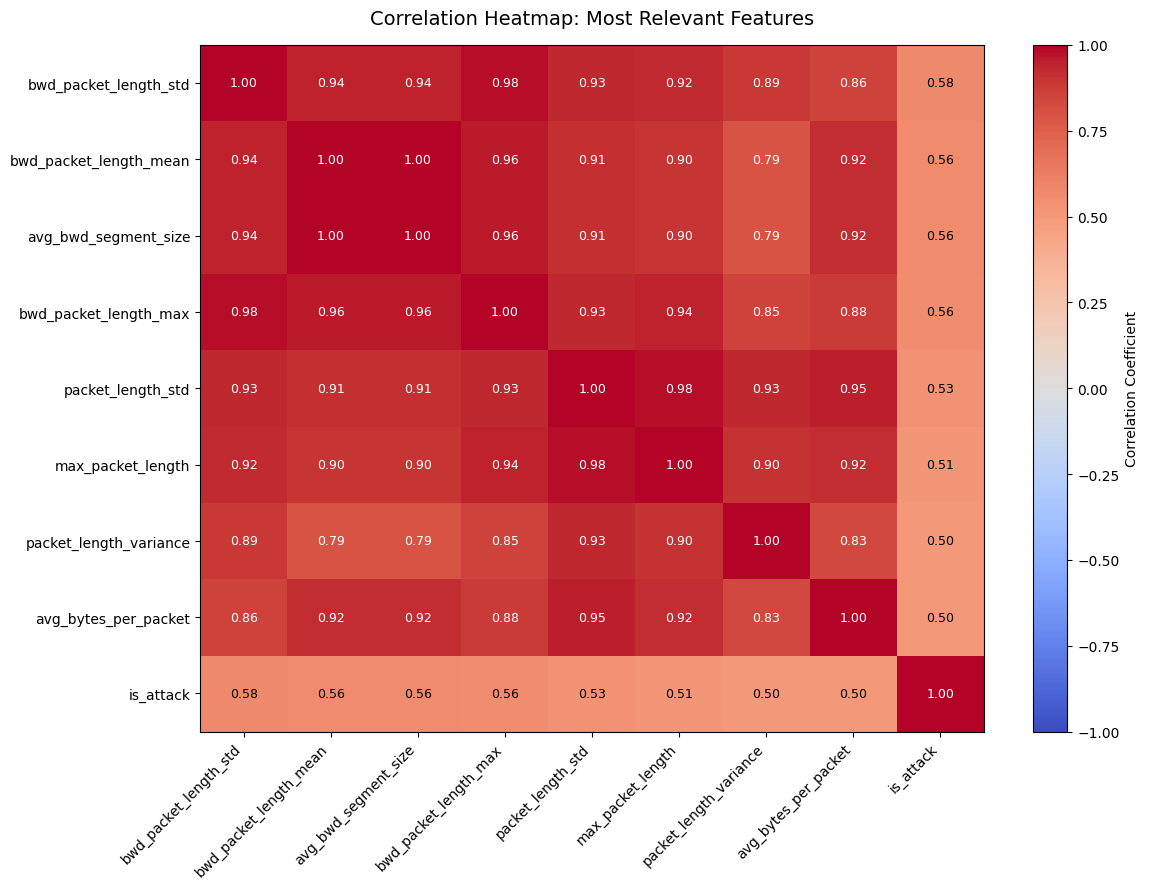

,bwd_packet_length_std,bwd_packet_length_mean,avg_bwd_segment_size,bwd_packet_length_max,packet_length_std,max_packet_length,packet_length_variance,avg_bytes_per_packet,is_attack
bwd_packet_length_std,1.000000,0.942326,0.942326,0.983133,0.934998,0.923546,0.888651,0.859375,0.577005
bwd_packet_length_mean,0.942326,1.000000,1.000000,0.959172,0.911050,0.895399,0.789568,0.921598,0.562562
avg_bwd_segment_size,0.942326,1.000000,1.000000,0.959172,0.911050,0.895399,0.789568,0.921598,0.562562
bwd_packet_length_max,0.983133,0.959172,0.959172,1.000000,0.931303,0.938314,0.850077,0.881867,0.561920
packet_length_std,0.934998,0.911050,0.911050,0.931303,1.000000,0.983644,0.929730,0.951074,0.533636
max_packet_length,0.923546,0.895399,0.895399,0.938314,0.983644,1.000000,0.899363,0.919600,0.513703
packet_length_variance,0.888651,0.789568,0.789568,0.850077,0.929730,0.899363,1.000000,0.828974,0.503395
avg_bytes_per_packet,0.859375,0.921598,0.921598,0.881867,0.951074,0.919600,0.828974,1.000000,0.500532
is_attack,0.577005,0.562562,0.562562,0.561920,0.533636,0.513703,0.503395,0.500532,1.000000


In [21]:
# Plot 6: Clear Correlation Heatmap
# Select the top 8 features most correlated with the target
top_feature_names = (
    correlations
    .head(8)
    .index
    .to_arrow()
    .to_pylist()
)

heatmap_columns = top_feature_names + ["is_attack"]

# Calculate correlation matrix
corr_matrix = (
    df[heatmap_columns]
    .corr()
    .to_pandas()
)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    aspect="auto",
    cmap="coolwarm"
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation Coefficient")

# Axis labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    corr_matrix.index
)

# Add correlation values inside each cell
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):

        value = corr_matrix.iloc[i, j]

        text_color = (
            "white"
            if abs(value) > 0.65
            else "black"
        )

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )

# Title
ax.set_title(
    "Correlation Heatmap: Most Relevant Features",
    fontsize=14,
    pad=15
)

plt.tight_layout()
plt.show()

corr_matrix

The heatmap shows that the selected features have moderate positive correlations with the attack target, ranging from about 0.50 to 0.58. bwd_packet_length_std has the strongest correlation with is_attack at 0.58. The features are also highly correlated with each other and which indicates that several of them capture similar packet size information.

## 15. Final Feature Set

After cleaning,feature engineering,and EDA, I remove analysis only columns and prepare the final matrix for machine learning.

In [22]:
analysis_only_columns = [
    col for col in [LABEL_COLUMN, "source_file"]
    if col in df.columns
]

feature_columns = [
    col for col in df.columns
    if col not in analysis_only_columns + ["is_attack"]
]

X = df[feature_columns].astype("float32")
y = df["is_attack"].astype("int32")

print("Final modeling rows:", f"{len(X):,}")
print("Final feature count:", len(feature_columns))
print("Engineered features used:", engineered_features)
print("\nTarget distribution:")
print(y.value_counts().sort_index())

Final modeling rows: 1,373,802
Final feature count: 72
Engineered features used: ['avg_bytes_per_packet', 'fwd_bwd_packet_ratio']

Target distribution:
is_attack
0    1072232
1     301570
Name: count, dtype: int64


## 16. Train/Test Split

The test set keeps the natural distribution. To reduce severe imbalance and majority-class downsampling is applied only to the training data.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=RANDOM_STATE,shuffle=True,)

print("Training rows:", f"{len(X_train):,}")
print("Testing rows:", f"{len(X_test):,}")
print("\nTraining distribution before balancing:")
print(y_train.value_counts().sort_index())

Training rows: 1,099,041
Testing rows: 274,761

Training distribution before balancing:
is_attack
0    857773
1    241268
Name: count, dtype: int64


In [24]:
if BALANCE_TRAINING:
    train_frame = X_train.copy()
    train_frame["is_attack"] = y_train

    attack_rows = train_frame[train_frame["is_attack"] == 1]
    benign_rows = train_frame[train_frame["is_attack"] == 0]

    maximum_benign = min(
        len(benign_rows),
        int(len(attack_rows) * MAX_BENIGN_TO_ATTACK_RATIO),
    )

    if maximum_benign < len(benign_rows):
        benign_rows = benign_rows.sample(
            n=maximum_benign,
            random_state=RANDOM_STATE,
        )

    balanced_frame = cudf.concat(
        [attack_rows, benign_rows],
        ignore_index=True,
    ).sample(
        frac=1.0,
        random_state=RANDOM_STATE,
    )

    y_train = balanced_frame.pop("is_attack")
    X_train = balanced_frame

    del train_frame, attack_rows, benign_rows, balanced_frame
    gc.collect()

print("Final training rows:", f"{len(X_train):,}")
print("Final training distribution:")
print(y_train.value_counts().sort_index())

Final training rows: 965,072
Final training distribution:
is_attack
0    723804
1    241268
Name: count, dtype: int64


## 17. Feature Scaling

Scaling is applied for Logistic Regression and Linear SVC. Random Forest uses the original feature scale.

In [25]:
with GPUMonitor() as scaling_monitor:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

scaling_metrics = scaling_monitor.summary(prefix="scaling_")
print(scaling_metrics)

{'scaling_time_seconds': 2.297279202000027, 'scaling_avg_gpu_util_percent': np.float64(28.363636363636363), 'scaling_max_gpu_util_percent': 100.0, 'scaling_avg_memory_used_mb': np.float64(4634.005681818182), 'scaling_max_memory_used_mb': 4790.1875}


## 18. Model Evaluation Functions

In [26]:
def to_numpy(value):
    if isinstance(
        value,
        (cudf.Series, cudf.DataFrame),
    ):
        return value.to_numpy()

    if hasattr(value, "get"):
        return value.get()

    return np.asarray(value)

def calculate_classification_metrics(
    y_true_gpu,
    y_pred_gpu,
):
    y_true = (
        to_numpy(y_true_gpu)
        .astype(int)
        .reshape(-1)
    )
    y_pred = (
        to_numpy(y_pred_gpu)
        .astype(int)
        .reshape(-1)
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(
            y_true,
            y_pred,
        ),
        "classification_report":
            classification_report(
                y_true,
                y_pred,
                target_names=["Benign", "Attack"],
                digits=4,
                zero_division=0,
            ),
    }

def run_classifier(
    model_name,
    model,
    train_features,
    test_features,
):
    with GPUMonitor() as training_monitor:
        model.fit(train_features, y_train)

    with GPUMonitor() as inference_monitor:
        predictions = model.predict(test_features)

    metrics = calculate_classification_metrics(
        y_test,
        predictions,
    )

    print(f"\n{model_name}")
    print("=" * len(model_name))
    print(metrics["classification_report"])
    print("Confusion matrix:")
    print(metrics["confusion_matrix"])

    result = {
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        **training_monitor.summary(prefix="train_"),
        **inference_monitor.summary(
            prefix="inference_"
        ),
    }

    return result, predictions, model

## 19. Model 1 - Logistic Regression

In [27]:
logistic_model = LogisticRegression(
    max_iter=1000,
    tol=1e-4,
    C=1.0,
)

logistic_result, logistic_predictions, logistic_model = (
    run_classifier(
        "cuML Logistic Regression",
        logistic_model,
        X_train_scaled,
        X_test_scaled,
    )
)

[2026-08-09 17:13:02.656] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)

cuML Logistic Regression
              precision    recall  f1-score   support

      Benign     0.9690    0.9627    0.9659    214459
      Attack     0.8705    0.8905    0.8804     60302

    accuracy                         0.9469    274761
   macro avg     0.9197    0.9266    0.9231    274761
weighted avg     0.9474    0.9469    0.9471    274761

Confusion matrix:
[[206468   7991]
 [  6601  53701]]


## 20. Model 2 - Random Forest Classifier

In [28]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    max_features="sqrt",
    n_bins=128,
    random_state=RANDOM_STATE,
)

rf_result, rf_predictions, random_forest_model = (
    run_classifier(
        "cuML Random Forest",
        random_forest_model,
        X_train,
        X_test,
    )
)


cuML Random Forest
              precision    recall  f1-score   support

      Benign     0.9985    0.9990    0.9987    214459
      Attack     0.9966    0.9945    0.9955     60302

    accuracy                         0.9980    274761
   macro avg     0.9975    0.9968    0.9971    274761
weighted avg     0.9980    0.9980    0.9980    274761

Confusion matrix:
[[214253    206]
 [   331  59971]]


## 21. Model 3 - Linear Support Vector Classifier

In [29]:
linear_svc_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    tol=1e-4,
)

svc_result, svc_predictions, linear_svc_model = (
    run_classifier(
        "cuML Linear SVC",
        linear_svc_model,
        X_train_scaled,
        X_test_scaled,
    )
)


cuML Linear SVC
              precision    recall  f1-score   support

      Benign     0.9628    0.9606    0.9617    214459
      Attack     0.8609    0.8680    0.8644     60302

    accuracy                         0.9403    274761
   macro avg     0.9119    0.9143    0.9131    274761
weighted avg     0.9404    0.9403    0.9403    274761

Confusion matrix:
[[206004   8455]
 [  7960  52342]]


## 22. Model Comparison

In [30]:
results = pd.DataFrame([
    logistic_result,
    rf_result,
    svc_result,
]).sort_values(
    "f1_score",
    ascending=False,
).reset_index(drop=True)

results

,model,accuracy,precision,recall,f1_score,train_time_seconds,train_avg_gpu_util_percent,train_max_gpu_util_percent,train_avg_memory_used_mb,train_max_memory_used_mb,inference_time_seconds,inference_avg_gpu_util_percent,inference_max_gpu_util_percent,inference_avg_memory_used_mb,inference_max_memory_used_mb
0,cuML Random Forest,0.998046,0.996577,0.994511,0.995543,18.286441,97.244444,100.0,4972.676389,4974.1875,0.311667,18.0,18.0,4702.1875,4702.1875
1,cuML Logistic Regression,0.946892,0.870469,0.890534,0.880388,2.693004,66.230769,83.0,4860.802885,4882.1875,0.063987,NaN,NaN,NaN,NaN
2,cuML Linear SVC,0.940257,0.860931,0.867998,0.864450,0.225556,10.000000,10.0,4910.187500,4910.1875,0.027167,NaN,NaN,NaN,NaN


Random Forest achieved the best performance 99.55% F1-score but required more training time and while Linear SVC was the fastest 0.63 s with lower accuracy. This shows a trade-off between accuracy and computational efficiency.

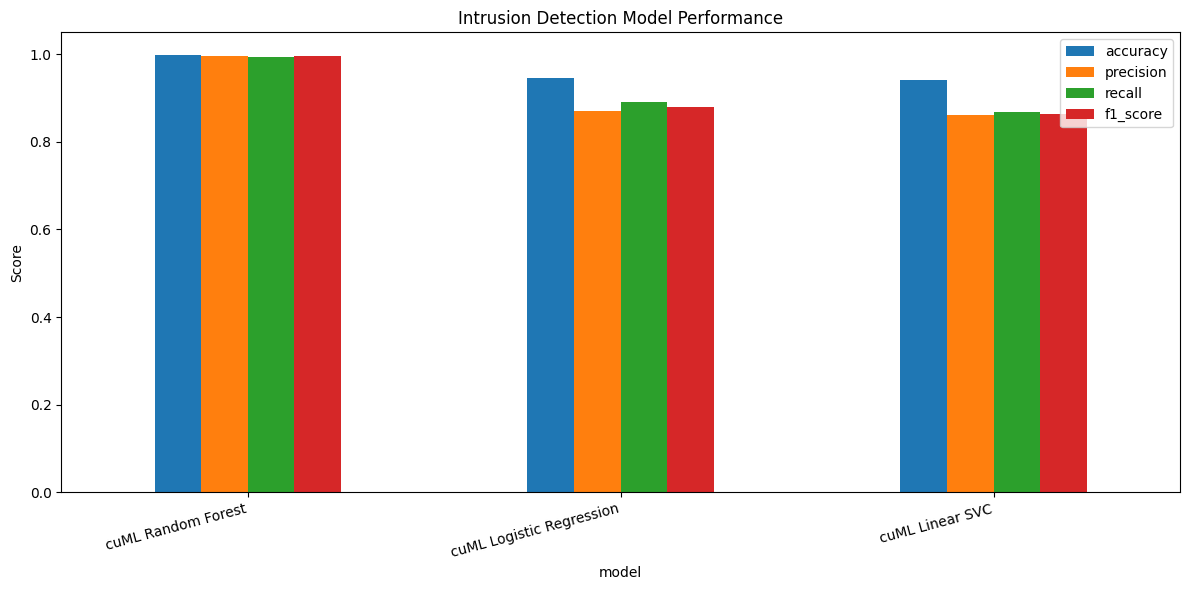

In [31]:
results.set_index("model")[
    ["accuracy", "precision", "recall", "f1_score"]
].plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title("Intrusion Detection Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

cuML Random Forest performed the best across all evaluation metrics and while Logistic Regression and Linear SVC showed lower performance. And Random Forest is the best model for this intrusion detection task.

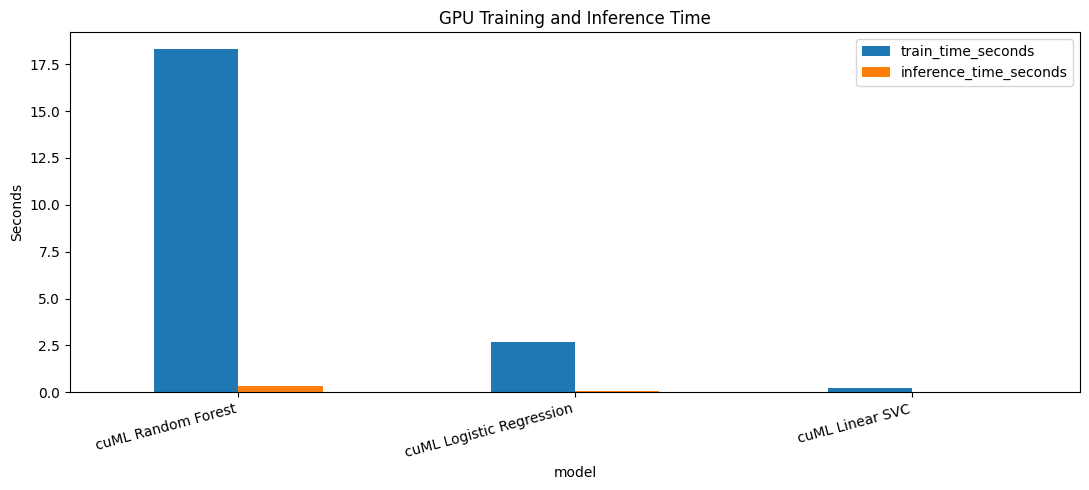

In [32]:
results.set_index("model")[
    ["train_time_seconds", "inference_time_seconds"]
].plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("GPU Training and Inference Time")
plt.ylabel("Seconds")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

Linear SVC is the fastest model and Random Forest takes the longest training time. This shows a trade-off between computational speed and model performance.

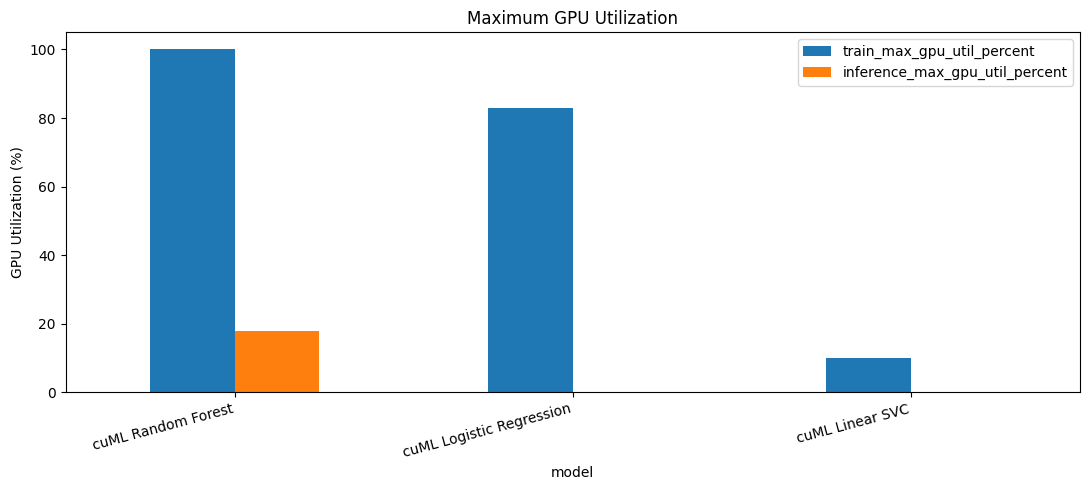

In [33]:
results.set_index("model")[
    [
        "train_max_gpu_util_percent",
        "inference_max_gpu_util_percent",
    ]
].plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("Maximum GPU Utilization")
plt.ylabel("GPU Utilization (%)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

GPU utilization is much higher during training than inference. Random Forest uses the GPU the most during training, reaching 100%, while inference requires fewer GPU resources.

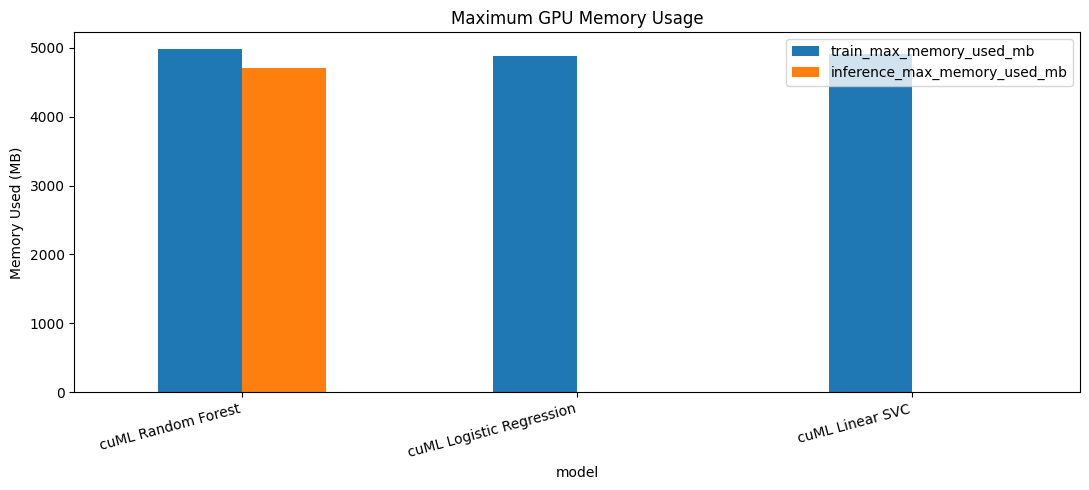

In [34]:
results.set_index("model")[
    [
        "train_max_memory_used_mb",
        "inference_max_memory_used_mb",
    ]
].plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("Maximum GPU Memory Usage")
plt.ylabel("Memory Used (MB)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

All three models use a similar amount of GPU memory around 5 GB with slightly higher memory usage during training than inference.

## 23. Workflow-Level GPU Metrics

In [36]:
# Clean GPU Workflow Performance Table
workflow_metrics = pd.DataFrame([
    {
        "Operation": "Data Loading (cuDF)",
        "Time (s)": load_metrics["load_time_seconds"],
        "Avg GPU (%)": load_metrics["load_avg_gpu_util_percent"],
        "Max GPU (%)": load_metrics["load_max_gpu_util_percent"],
        "Avg Memory (MB)": load_metrics["load_avg_memory_used_mb"],
        "Max Memory (MB)": load_metrics["load_max_memory_used_mb"],
    },

    {
        "Operation": "Data Cleaning (cuDF)",
        "Time (s)": preprocessing_metrics[
            "preprocessing_time_seconds"
        ],
        "Avg GPU (%)": preprocessing_metrics[
            "preprocessing_avg_gpu_util_percent"
        ],
        "Max GPU (%)": preprocessing_metrics[
            "preprocessing_max_gpu_util_percent"
        ],
        "Avg Memory (MB)": preprocessing_metrics[
            "preprocessing_avg_memory_used_mb"
        ],
        "Max Memory (MB)": preprocessing_metrics[
            "preprocessing_max_memory_used_mb"
        ],
    },

    {
        "Operation": "Feature Scaling (cuML)",
        "Time (s)": scaling_metrics["scaling_time_seconds"],
        "Avg GPU (%)": scaling_metrics[
            "scaling_avg_gpu_util_percent"
        ],
        "Max GPU (%)": scaling_metrics[
            "scaling_max_gpu_util_percent"
        ],
        "Avg Memory (MB)": scaling_metrics[
            "scaling_avg_memory_used_mb"
        ],
        "Max Memory (MB)": scaling_metrics[
            "scaling_max_memory_used_mb"
        ],
    },
])

# Round values for cleaner presentation
numeric_columns = workflow_metrics.select_dtypes(
    include="number"
).columns

workflow_metrics[numeric_columns] = (
    workflow_metrics[numeric_columns].round(2)
)

workflow_metrics

,Operation,Time (s),Avg GPU (%),Max GPU (%),Avg Memory (MB),Max Memory (MB)
0,Data Loading (cuDF),2.99,21.00,48.0,1739.11,4166.19
1,Data Cleaning (cuDF),3.53,30.88,55.0,2945.83,3212.19
2,Feature Scaling (cuML),2.30,28.36,100.0,4634.01,4790.19


Feature Scaling was the fastest operation (2.30 s) and reached the highest GPU utilization (100%) and Data Cleaning took the longest time (3.53 s). Overall the GPU handled the workflow efficiently.

## 24. Controlled CPU vs GPU Comparison

The same reproducible subset and Logistic Regression setup are used for timing.

In [37]:
from sklearn.preprocessing import (
    StandardScaler as CPUStandardScaler,
)
from sklearn.linear_model import (
    LogisticRegression as CPULogisticRegression,
)

comparison_rows = min(
    CPU_BASELINE_ROWS,
    len(X_train),
)

X_cpu = X_train.head(
    comparison_rows
).to_pandas()

y_cpu = y_train.head(
    comparison_rows
).to_pandas()

cpu_start = time.perf_counter()

cpu_scaler = CPUStandardScaler()
X_cpu_scaled = cpu_scaler.fit_transform(X_cpu)

cpu_model = CPULogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

cpu_model.fit(
    X_cpu_scaled,
    y_cpu,
)

cpu_elapsed = time.perf_counter() - cpu_start

print(
    f"CPU Logistic Regression time: "
    f"{cpu_elapsed:.3f} seconds"
)

CPU Logistic Regression time: 22.569 seconds


The CPU baseline took 22.57 seconds and providing a reference point for measuring the speedup achieved with GPU acceleration.

In [38]:
X_gpu_subset = X_train.head(comparison_rows)
y_gpu_subset = y_train.head(comparison_rows)

gpu_start = time.perf_counter()

gpu_subset_scaler = StandardScaler()
X_gpu_subset_scaled = (
    gpu_subset_scaler.fit_transform(
        X_gpu_subset
    )
)

gpu_subset_model = LogisticRegression(
    max_iter=1000,
)

gpu_subset_model.fit(
    X_gpu_subset_scaled,
    y_gpu_subset,
)

gpu_elapsed = time.perf_counter() - gpu_start

speedup = (
    cpu_elapsed / gpu_elapsed
    if gpu_elapsed > 0
    else np.nan
)

cpu_gpu_comparison = pd.DataFrame({
    "environment": [
        "CPU - scikit-learn",
        "GPU - cuML",
    ],
    "rows": [
        comparison_rows,
        comparison_rows,
    ],
    "time_seconds": [
        cpu_elapsed,
        gpu_elapsed,
    ],
})

print(cpu_gpu_comparison)
print(f"Observed GPU speedup: {speedup:.2f}x")

          environment    rows  time_seconds
0  CPU - scikit-learn  250000     22.568548
1          GPU - cuML  250000      1.547914
Observed GPU speedup: 14.58x


For the same 250,000 rows and the GPU was about 14.58× faster than the CPU reducing the execution time from 22.57 to 1.55 seconds. This shows the efficiency of GPU acceleration for large datasets.

## 25. Save Final Results

In [39]:
output_dir = Path(
    "/content/cybershield_results"
)
output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

results.to_csv(
    output_dir / "model_comparison.csv",
    index=False,
)

workflow_metrics.to_csv(
    output_dir / "workflow_gpu_metrics.csv",
    index=False,
)

cpu_gpu_comparison.to_csv(
    output_dir / "cpu_gpu_comparison.csv",
    index=False,
)

project_summary = {
    "loaded_rows": int(len(df)),
    "feature_count": int(len(feature_columns)),
    "best_model": str(results.iloc[0]["model"]),
    "best_accuracy": float(
        results.iloc[0]["accuracy"]
    ),
    "best_precision": float(
        results.iloc[0]["precision"]
    ),
    "best_recall": float(
        results.iloc[0]["recall"]
    ),
    "best_f1_score": float(
        results.iloc[0]["f1_score"]
    ),
    "cpu_gpu_speedup": float(speedup),
}

with open(
    output_dir / "project_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        project_summary,
        file,
        indent=2,
    )

for path in output_dir.iterdir():
    print(path)

/content/cybershield_results/workflow_gpu_metrics.csv
/content/cybershield_results/project_summary.json
/content/cybershield_results/cpu_gpu_comparison.csv
/content/cybershield_results/model_comparison.csv


In [40]:
# Optional downloads.
from google.colab import files

for filename in [
    "model_comparison.csv",
    "workflow_gpu_metrics.csv",
    "cpu_gpu_comparison.csv",
    "project_summary.json",
]:
    files.download(
        str(output_dir / filename)
    )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 26. Final Discussion

### Feature Engineering

- Engineered features created: 2
- Engineered features: `avg_bytes_per_packet` and `fwd_bwd_packet_ratio`
- The EDA showed that `avg_bytes_per_packet` was the more useful engineered feature because it showed a clearer difference between benign and attack traffic. In comparison, `fwd_bwd_packet_ratio` showed similar median values for both classes.

### Dataset

- Loaded rows: 1,500,000
- Final rows after cleaning: 1,373,802
- Features used for modeling: 72

The dataset was cleaned by removing duplicate records, handling missing and infinite values, and removing constant features. The final dataset was used to classify network traffic as either benign or attack.

### Best Predictive Model

- Model: cuML Random Forest
- Accuracy: 99.80%
- Precision: 99.66%
- Recall: 99.45%
- F1-score: 99.55%

The cuML Random Forest achieved the best overall performance among the three models. Its high recall is especially important for intrusion detection because the model successfully detected most of the attack traffic.

### GPU Performance

- Fastest training model: cuML Linear SVC
- Fastest inference model: cuML Linear SVC
- Highest GPU utilization: cuML Random Forest (100%)
- Highest GPU memory usage: cuML Random Forest
- Controlled CPU/GPU speedup: 14.58x

The GPU experiment showed a clear performance improvement. For the same 250,000 rows, the CPU implementation took about 22.57 seconds and while the GPU implementation took about 1.55 seconds. This resulted in approximately 14.58x speedup showing the benefit of GPU acceleration for large-scale machine learning.

### Trade-off

The results show a trade-off between predictive performance and computational efficiency. Linear SVC was the fastest model, but its classification performance was lower than Random Forest. Random Forest required more training time and GPU resources, but it achieved the highest accuracy, recall, and F1-score.

For this intrusion detection task, **cuML Random Forest is the recommended model** because accurately detecting attacks is more important than achieving the fastest training time.

### Limitations

1. CIC-IDS2017 represents a controlled network environment and may not fully represent real-world network traffic.
2. Real production traffic may contain different patterns and newer types of attacks.
3. The current project uses binary classification and does not identify the specific attack type.
4. Class balancing was applied only to the training data, while the test data kept its original distribution.
5. Changes in network traffic over time may reduce model performance due to concept drift.
6. This project is an academic prototype and is not intended to replace a complete cybersecurity platform.

### Future Work

- Extend the system to multiclass classification to identify specific attack types.
- Implement real-time network traffic detection.
- Use SHAP or feature importance to explain model predictions.
- Tune the classification threshold to improve attack detection.
- Explore multi-GPU processing using Dask-cuDF for larger datasets.
- Evaluate the models on newer intrusion detection datasets.

## 27. Conclusion

CyberShield AI successfully demonstrates an end-to-end GPU-accelerated workflow for network intrusion detection using the CIC-IDS2017 dataset. The project processed 1.5 million network traffic records using cuDF for large-scale data processing and cuML for machine learning.

Three classification models were evaluated: Logistic Regression, Random Forest, and Linear SVC. Among them, cuML Random Forest achieved the best overall performance, with 99.80% accuracy, 99.66% precision, 99.45% attack recall, and 99.55% F1-score. These results make Random Forest the most suitable model for this intrusion detection task, where correctly detecting malicious traffic is especially important.

The project also demonstrated the benefit of GPU acceleration. In the controlled CPU/GPU comparison using 250,000 rows the GPU completed the same Logistic Regression workflow approximately 14.58x faster than the CPU reducing execution time from about 22.57 seconds to 1.55 seconds.

Overall, the results show that GPU-accelerated machine learning can provide both high predictive performance and efficient processing for large-scale cybersecurity data. CyberShield AI therefore demonstrates how GPU computing can support fast and effective network intrusion detection.